# Performance Notebook 3

# Lecture 8: Computer Arithmetic & Numerical Accuracy

## Before M1: what are we looking at?
To see specific what we are looking at i have decided to zoom out a bit at first to see where we are 

In [74]:
import numpy as np
import matplotlib.pyplot as plt

def escape_and_divergence_maps_larger(N: int,MAX_ITER: int,TAU: float):
    x = np.linspace(-0.8, -0.7, N)
    y = np.linspace(0.05, 0.15, N)
    C64 = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
    C32 = C64.astype(np.complex64)

    z32 = np.zeros_like(C32)
    z64 = np.zeros_like(C64)

    # Divergence tracking
    diverge = np.full((N, N), MAX_ITER, dtype=np.int32)
    active = np.ones((N, N), dtype=bool)

    # Escape tracking
    escape_iter = np.full((N, N), MAX_ITER, dtype=np.int32)
    escaped = np.zeros((N, N), dtype=bool)

    for k in range(MAX_ITER):
        if not active.any():
            break

        # iterate both precisions
        z32[active] = z32[active]**2 + C32[active]
        z64[active] = z64[active]**2 + C64[active]

        # divergence
        diff = (
            np.abs(z32.real.astype(np.float64) - z64.real)
            + np.abs(z32.imag.astype(np.float64) - z64.imag)
        )

        newly_div = active & (diff > TAU)
        diverge[newly_div] = k
        active[newly_div] = False

        # escape count 
        mag = np.abs(z64)
        newly_esc = (~escaped) & (mag > 2)

        escape_iter[newly_esc] = k
        escaped[newly_esc] = True

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Divergence map
    im1 = ax[0].imshow(
        diverge,
        cmap='plasma',
        origin='lower',
        extent=[-1, -0.5, 0, 0.5]
    )
    ax[0].set_title(f'Divergence (tau={TAU})')
    fig.colorbar(im1, ax=ax[0],label=
    'First divergence iteration')

    # Escape map
    im2 = ax[1].imshow(
        escape_iter,
        cmap='viridis',
        origin='lower',
        extent=[-1, -0.5, 0, 0.5]
    )
    ax[1].set_title('Escape count')
    fig.colorbar(im2, ax=ax[1])

    plt.tight_layout()
    plt.show()
    amount_diverged = np.sum(diverge < MAX_ITER)
    fraction_diverged = amount_diverged / ( N * N)
    print(f"Fraction diverged for {TAU=}:", fraction_diverged)
    amount_diverged_500 = np.sum(diverge < 500)
    fraction_diverged_500 = 1 -( amount_diverged_500 / ( N * N))
    print(f"Fraction diverged above 500 iterations {TAU=}:", fraction_diverged_500)

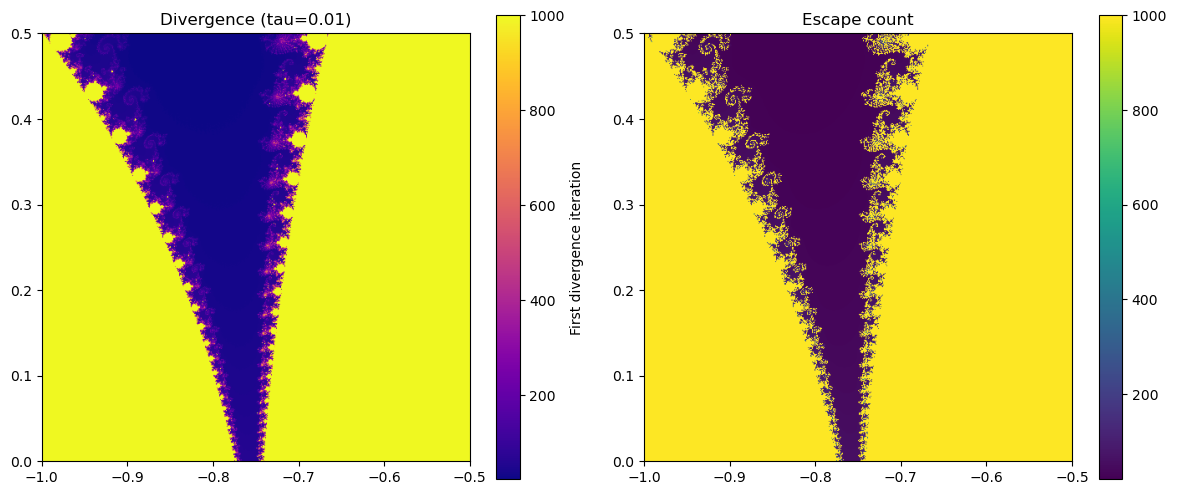

Fraction diverged for TAU=0.01: 0.2910499572753906
Fraction diverged above 500 iterations TAU=0.01: 0.715484619140625


In [75]:
N, MAX_ITER = 512, 1000
TAUS=[0.01,0.5,5]
escape_and_divergence_maps_larger(N,MAX_ITER,TAUS[0])

## M1: Mandelbrot Trajectory Divergence

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def escape_and_divergence_maps(N: int,MAX_ITER: int,TAU: float):
    x = np.linspace(-0.7530, -0.7490, N)
    y = np.linspace(0.0990, 0.1030, N)

    C64 = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
    C32 = C64.astype(np.complex64)

    z32 = np.zeros_like(C32)
    z64 = np.zeros_like(C64)

    # Divergence tracking
    diverge = np.full((N, N), MAX_ITER, dtype=np.int32)
    active = np.ones((N, N), dtype=bool)

    # Escape tracking
    escape_iter = np.full((N, N), MAX_ITER, dtype=np.int32)
    escaped = np.zeros((N, N), dtype=bool)

    for k in range(MAX_ITER):
        if not active.any():
            break

        # iterate both precisions
        z32[active] = z32[active]**2 + C32[active]
        z64[active] = z64[active]**2 + C64[active]

        # divergence
        diff = (
            np.abs(z32.real.astype(np.float64) - z64.real)
            + np.abs(z32.imag.astype(np.float64) - z64.imag)
        )

        newly_div = active & (diff > TAU)
        diverge[newly_div] = k
        active[newly_div] = False

        # escape count 
        mag = np.abs(z64)
        newly_esc = (~escaped) & (mag > 2)

        escape_iter[newly_esc] = k
        escaped[newly_esc] = True

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Divergence map
    im1 = ax[0].imshow(
        diverge,
        cmap='plasma',
        origin='lower',
        extent=[-0.7530, -0.7490, 0.0990, 0.1030]
    )
    ax[0].set_title(f'Divergence (tau={TAU})')
    fig.colorbar(im1, ax=ax[0],label=
    'First divergence iteration')

    # Escape map
    im2 = ax[1].imshow(
        escape_iter,
        cmap='viridis',
        origin='lower',
        extent=[-0.7530, -0.7490, 0.0990, 0.1030]
    )
    ax[1].set_title('Escape count')
    fig.colorbar(im2, ax=ax[1])

    plt.tight_layout()
    plt.show()
    print(f" The Max iteration for any pixel to diverge for {TAU=} is {np.max(diverge)}")
    amount_diverged = np.sum(diverge < MAX_ITER)
    fraction_diverged = amount_diverged / ( N * N)
    print(f"Fraction diverged for {TAU=}:", fraction_diverged)
    amount_diverged_500 = np.sum(diverge < 500)
    fraction_diverged_500 = 1 -( amount_diverged_500 / ( N * N))
    print(f"Fraction diverged above 500 iterations {TAU=}:", fraction_diverged_500)

    idx = np.nanargmax(diverge)
    i, j = np.unravel_index(idx, diverge.shape)
    print(f"X,Y Coordinate for highest iteration for divergence: {C64[i, j]} With iters of {diverge[i, j]}")

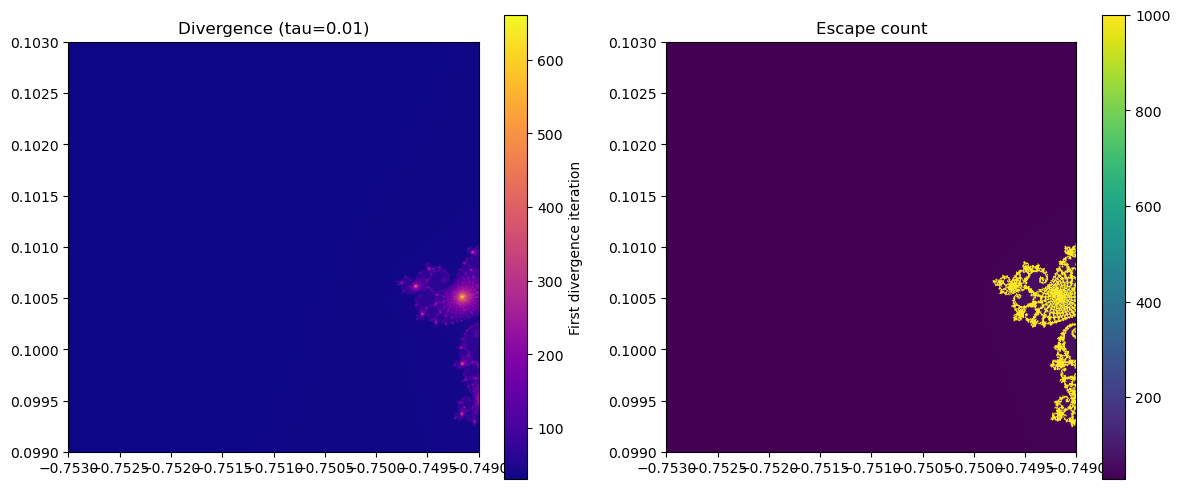

 The Max iteration for any pixel to diverge for TAU=0.01 is 661
Fraction diverged for TAU=0.01: 1.0
Fraction diverged above 500 iterations TAU=0.01: 3.814697265625e-05
X,Y Coordinate for highest iteration for divergence: (-0.7491565557729941+0.10051076320939335j) With iters of 661


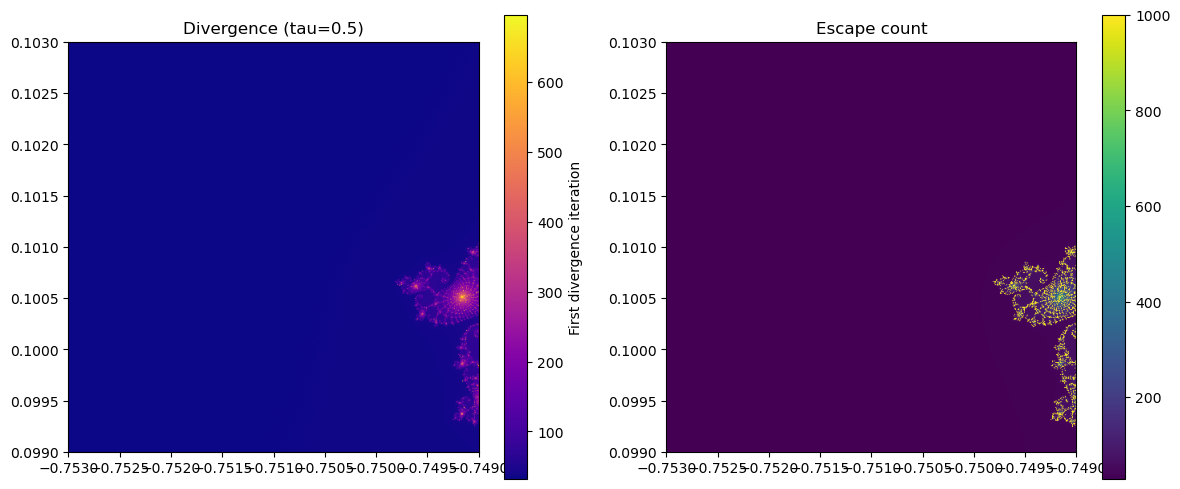

 The Max iteration for any pixel to diverge for TAU=0.5 is 696
Fraction diverged for TAU=0.5: 1.0
Fraction diverged above 500 iterations TAU=0.5: 0.000141143798828125
X,Y Coordinate for highest iteration for divergence: (-0.7491565557729941+0.10051076320939335j) With iters of 696


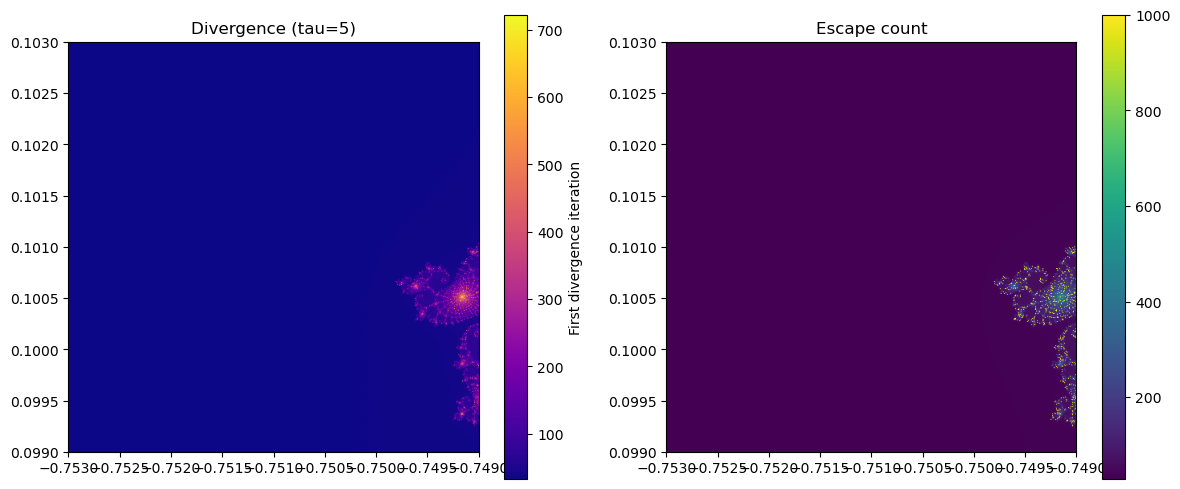

 The Max iteration for any pixel to diverge for TAU=5 is 722
Fraction diverged for TAU=5: 1.0
Fraction diverged above 500 iterations TAU=5: 0.000186920166015625
X,Y Coordinate for highest iteration for divergence: (-0.749133072407045+0.10051859099804306j) With iters of 722


In [57]:
N, MAX_ITER = 512, 1000
TAUS=[0.01,0.5,5]
for TAU in TAUS:
    escape_and_divergence_maps(N,MAX_ITER,TAU)

### What fraction of pixels diverge before max iter?
MAX_ITER is set to 1000, it can be observed that the Fraction diverged = 1 for the three TAUS i have set, meaning that all pixels result in a difference between float32 and float64 exceeding TAU, before 1000 iterations

To set another measure 500 is also used to see. Fraction diverged above 500 iterations, and seing how this responds depending on TAU.

Where it can be observed what is expected as we set TAU higher more pixel need more iterations for diverging

### Where do trajectories diverge early? Compare visually to the escape-count map.
It can be observed that alot of them deverge earlier specifcally not the region of x = [-0.7500,-0.7490] y=[0.1015,0.0995], which can also be related over to the escape map where we generally see these points also having escaped eariler.

If we instead do look at the region of x = [-0.7500,-0.7490] y=[0.1015,0.0995]. We can observe that earlier devirgence result in higher escape count. 
Seen as when we change tau to an higher value the Fraction diverged above 500 iterations becomes higher and looking at the escape map it can be observe we get less yellow pixels (1000 iteration for escaping)

### Does early divergence correlate with high escape iteration counts?
Based on the region of x = [-0.7500,-0.7490] y=[0.1015,0.0995] yes we can clearly see this correlation between the two visually.

## M2: Mandelbrot Sensitivity Map

X,Y Coordinate for Max Kappa: (-0.7491956947162427+0.09999412915851272j) With value of 56279933.67272727


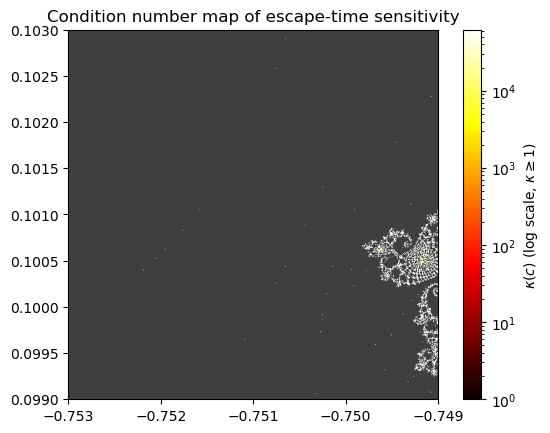

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

N, MAX_ITER = 512, 1000

x = np.linspace(-0.7530, -0.7490, N)
y = np.linspace(0.0990, 0.1030, N)

C = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)

eps32 = np.finfo(np.float32).eps
delta = np.maximum(eps32 * np.abs(C), 1e-10)


def escape_count(C, max_iter):
    z = np.zeros_like(C)
    cnt = np.full(C.shape, max_iter, dtype=np.int32)
    esc = np.zeros(C.shape, dtype=bool)

    for k in range(max_iter):
        z[~esc] = z[~esc]**2 + C[~esc]

        newly = (~esc) & (np.abs(z) > 2.0)
        cnt[newly] = k
        esc[newly] = True

    return cnt


n_base = escape_count(C, MAX_ITER).astype(float)
n_perturb = escape_count(C + delta, MAX_ITER).astype(float)

dn = np.abs(n_base - n_perturb)

kappa = np.where(n_base > 0, dn / (eps32 * n_base), np.nan)

# to find the indx of kappa max
idx = np.nanargmax(kappa)
i, j = np.unravel_index(idx, kappa.shape)
print(f"X,Y Coordinate for Max Kappa: {C[i, j]} With value of {kappa[i, j]}")

cmap_k = plt.cm.hot.copy()
cmap_k.set_bad('0.25')

vmax = np.nanpercentile(kappa, 99)

plt.imshow(
    kappa,
    cmap=cmap_k,
    origin='lower',
    extent=[-0.7530, -0.7490, 0.0990, 0.1030],
    norm=LogNorm(vmin=1, vmax=vmax)
)

plt.colorbar(label=r'$\kappa(c)$ (log scale, $\kappa \geq 1$)')
plt.title('Condition number map of escape-time sensitivity')
plt.show()


### Where is κ largest? Does it match the boundary in M1?
We can clearly regonize the same pattern of pixels form M1. 

Specifcally the point may not match but the pattern definately does.

If we compare to tau = 0.01 and find its point with most need iteration to diverge we have:

X,Y Coordinate for highest iteration for divergence: (-0.7491565557729941+0.10051076320939335j) With iters of 661

where we here in the sentivity map have it to be 

X,Y Coordinate for Max Kappa: (-0.7491956947162427+0.09999412915851272j) With value of 56279933.67272727

We can generally see the boundary from M1



### what is k for interior pixels (n = max_iter)?
we can generally see that that this are very low value from the dark pixels and more accurately if print kappa array, we can observe taht we get alot of 0s.

from which we can say that the pixels have close or equal to k = 0.

In [ ]:
print("Points for kappa")
print(kappa)


Points for kappa
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


which also make sense based of the formula

# Lecture 9: Testing & Documentation

## M1: Test Suite

Under can be found the result of the test ran further they can be found in:

All tests passed (24 tests run). Some warnings were raised by Numba related to parallel execution, indicating that the parallelisation was not fully applied by the compiler, but these do not affect correctness of the results

## M2: Docstrings and Type Hints 

All Docstrings and Type Hints are to found within mandelbort.py, an example is shown under of this

In [ ]:
from mandelbort import mandelbrot_point_naive

In [ ]:
def compute_mandelbrot_naive(x_min:float,x_max:float,y_min:float,y_max:float,num:int) -> np.ndarray: 
    """
    Compute the Mandelbrot set using a naive implementation.

    Each grid point corresponds to a complex number c = x + iy.
    The function iterates z = z^2 + c and records escape iterations.

    Parameters
    ----------
    x_min : float
        Minimum real axis value.
    x_max : float
        Maximum real axis value.
    y_min : float
        Minimum imaginary axis value.
    y_max : float
        Maximum imaginary axis value.
    num : int
        Grid resolution in both x and y directions.

    Returns
    -------
    np.ndarray
        2D array of iteration counts before escape.
    """
    all_c = []
    all_n = []

    x = np.linspace(x_min, x_max, num)   # real axis
    y = np.linspace(y_min, y_max, num)   # imaginary axis

    # 2D arrays to store results
    all_c = np.zeros((num, num), dtype=complex)  # create matrix of all c, num X num (empty)
    all_n = np.zeros((num, num), dtype=int)     # Create matrix of all n, num X num (empty)

    for i in range(num):        # Iterate over all c 
        for j in range(num):
            c = x[i] + 1j * y[j]
            n = mandelbrot_point_naive(c)     # comput iteration from c/constant

            all_c[i, j] = c             # save all c and iterations
            all_n[i, j] = n
    return all_n

# Lecture 10: GPU Computing — Introduction

## M1: GPU Mandelbrot: Mandelbrot Float32 Kerne

Have gotten two results of timings, where given the introstruction i get the result of:

Because of the error, and found that implementing it like seen under by setup kernel and then arguments for the kernel explicitly i would not have to re-fetching the kernel object from the compiled program result in a time of 

See in mandelbrot_gpu for how specifically

In [ ]:
from mandelbrot_gpu import mandelbrot_opencl_f32

## M2: GPU Mandelbrot: Float32 vs Float64

Have defined two function one for float 32 and one for float 64. The timings are:

GPU 1024x1024: 1.3 ms
GPU 1024x1024: 8.0 ms
GPU 2048x2048: 3.0 ms
GPU 2048x2048: 26.1 ms


0.026128700003027916

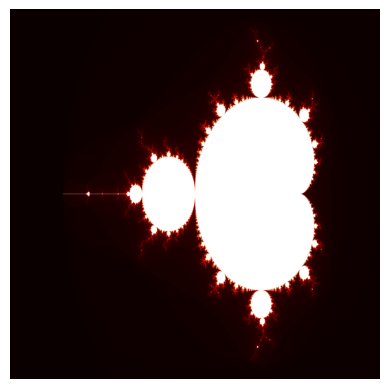

In [1]:
from mandelbrot_gpu import mandelbrot_opencl_f32, mandelbrot_opencl_f64
mandelbrot_opencl_f32(N=1024)
mandelbrot_opencl_f64(N=1024)
mandelbrot_opencl_f32(N=2048)
mandelbrot_opencl_f64(N=2048)

### Is the measured speed ratio consistent with your Roofline prediction?


still needs to be typed

## M3: GPU Mandelbrot: Benchmark GPU vs Earlier Results

Speedup and timings table for N=4096

GPU 4096x4096: 10.0 ms
GPU 4096x4096: 104.1 ms


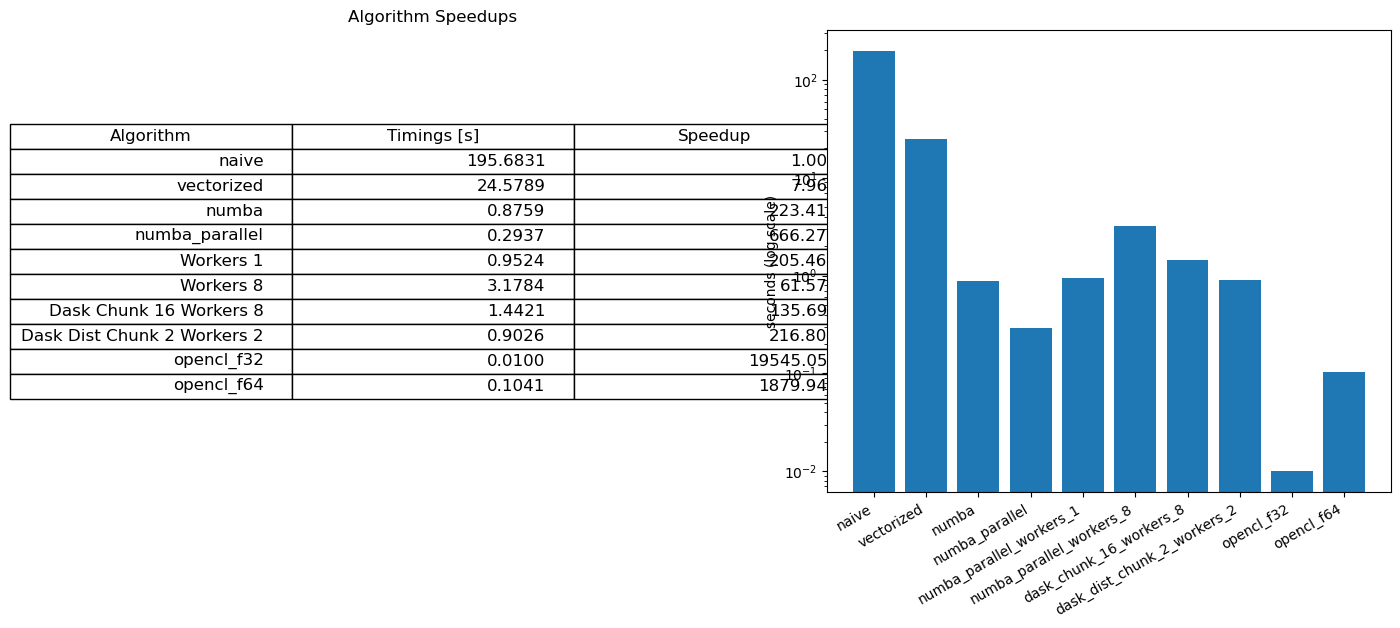

In [ ]:
import matplotlib.pyplot as plt
from mandelbrot_gpu import mandelbrot_opencl_f32,mandelbrot_opencl_f64
grid_res = 4096

n_runs = 1

# you already have this from previous run
timings = {
    4096: {
        "naive": 195.6831,
        "vectorized": 24.5789,
        "numba": 0.8759,
        "numba_parallel": 0.2937,
        "numba_parallel_workers_1": 0.9524,
        "numba_parallel_workers_8": 3.1784,
        "dask_chunk_16_workers_8": 1.4421,
        "dask_dist_chunk_2_workers_2": 0.9026
    }
}
timings[grid_res]["opencl_f32"] = mandelbrot_opencl_f32(N=grid_res)
timings[grid_res]["opencl_f64"] = mandelbrot_opencl_f64(N=grid_res)

first_key = list(timings[grid_res].keys())[0]
naive_time = timings[grid_res][first_key]

speedups = {}
for name, t in timings[grid_res].items():
    speedups[name] = naive_time / t
    # compute efficiency only for parallel runs

# create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# speedup table 
axes[0].axis("off")
table_data = []
for name in speedups.keys():
    s = speedups[name]
    t = timings[grid_res][name]
    if "dask_dist" in name:
        chunks = name.split("chunk_")[1].split("_")[0]
        workers = name.split("workers_")[1]
        name = f"Dask Dist Chunk {chunks} Workers {workers}"
    if "dask_chunk" in name:
        chunks = name.split("chunk_")[1].split("_")[0]
        workers = name.split("workers_")[1]
        name = f"Dask Chunk {chunks} Workers {workers}"
    elif "_chunk_" in name:
        chunks = name.split("chunk_")[1].split("_")[0]
        workers = name.split("workers_")[1]
        name = f"Chunk {chunks} Workers {workers}"
    elif "_workers_" in name:
        workers = name.split("workers_")[1]
        name = f"Workers {workers}"
    else:
        name = name
    table_data.append([
        name,
        f"{t:.4f}",
        f"{s:.2f}",
    ])
    table = axes[0].table(
        cellText=table_data,
        colLabels=["Algorithm","Timings [s]", "Speedup"],
        loc="center"
    )
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 1.5)
axes[0].set_title("Algorithm Speedups")

# im0 = axes[2].imshow(results[1024]["numba_lecture4"], cmap="hot")
# numba_lecture_time_1024= timings[1024]["numba_lecture4"]
# axes[2].set_title(f"Numba lecture 4 Mandelbrot\n Median time: {numba_lecture_time_1024:.2f} s")
# axes[2].axis("off")
# fig.colorbar(im0, ax=axes[2], fraction=0.046, pad=0.04)

results = timings[grid_res]

names, times = zip(*results.items())

axes[1].bar(names, times)
axes[1].set_yscale("log")
axes[1].set_ylabel("seconds (log scale)")
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, rotation=30, ha="right")
plt.tight_layout()
plt.show()
